# Backtracking Interpretability Pipeline

This notebook runs the full pipeline for probing reasoning model hidden states to predict answer correctness.

**API Options:**
- **OpenRouter API**: Generate CoT via API (no GPU needed for generation, only for hidden state extraction)
- **Local**: Run everything locally with HuggingFace transformers (requires GPU)

**Pipeline stages:**
1. Setup & data download
2. Generate Chain-of-Thought reasoning (API or local)
3. Chunk reasoning into segments
4. Label chunks with correctness/stability
5. Extract hidden states (requires local model)
6. Train probes

Based on [Zhang et al. (2025) "Verifier Probing"](https://arxiv.org/abs/2504.05419)

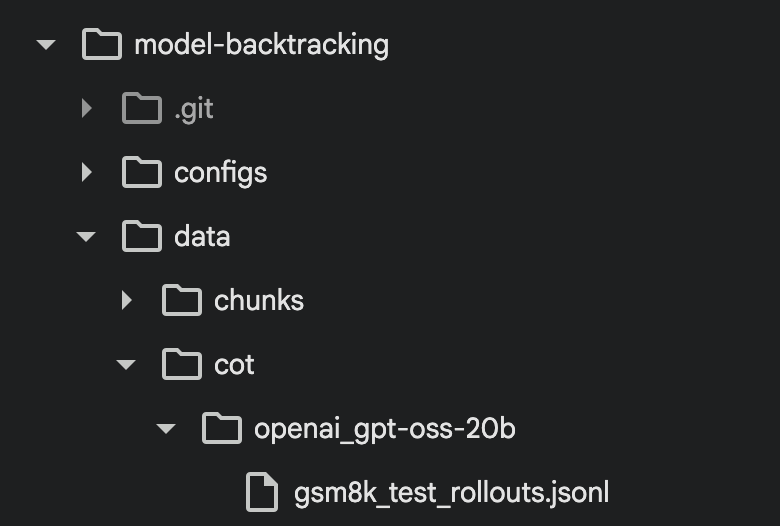

## 0. Setup

In [ ]:
# Check GPU
!nvidia-smi

Wed Jan  7 17:45:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# Clone the repo (or upload your local copy)
!git clone https://github.com/arfpog/model-backtracking.git
%cd model-backtracking

Cloning into 'model-backtracking'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 137 (delta 57), reused 113 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 67.03 KiB | 11.17 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/model-backtracking


In [ ]:
# Install dependencies
!pip install -q torch transformers accelerate datasets huggingface_hub sentencepiece
!pip install -q spacy scikit-learn tqdm pyyaml requests
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 130.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from huggingface_hub import login

## 1. Configuration

Choose between GSM8K (numeric) or MMLU-STEM (multiple choice):

In [ ]:
# ============================================
# API BACKEND: Choose one
# ============================================
# Option 1: OpenRouter API (no GPU needed for generation)
API_BACKEND = "openrouter"
MODEL_NAME = "deepseek/deepseek-r1"  # OpenRouter model ID
# MODEL_NAME = "qwen/qwq-32b"  # Alternative

# Option 2: Local HuggingFace (requires GPU)
# API_BACKEND = "local"
# MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

# For hidden state extraction, we need a local model
LOCAL_MODEL_FOR_HIDDEN = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

# ============================================
# DATASET: Choose one
# ============================================
# Option A: GSM8K (numeric math problems)
DATASET = "gsm8k_test"
ANSWER_TYPE = "numeric"

# Option B: MMLU-STEM (multiple choice)
# DATASET = "mmlu_stem"
# ANSWER_TYPE = "letter"

# ============================================
# GENERATION SETTINGS
# ============================================
MAX_EXAMPLES = 100        # Number of questions (None = full dataset)
NUM_ROLLOUTS = 3          # Rollouts per question (for diverse reasoning)
MAX_RETRIES = 3           # Retries for degenerate responses

# ============================================
# API KEY (for OpenRouter)
# ============================================
import os
# Set your API key here or use environment variable
# os.environ["OPENROUTER_API_KEY"] = "your-key-here"

if not os.environ.get("OPENROUTER_API_KEY"):
    print("WARNING: OPENROUTER_API_KEY not set!")

# Paths (auto-generated based on config)
model_slug = MODEL_NAME.replace("/", "_")
local_model_slug = LOCAL_MODEL_FOR_HIDDEN.replace("/", "_")
RAW_PATH = f"data/raw/{DATASET}.jsonl"
COT_PATH = f"data/cot/{model_slug}/{DATASET}_rollouts.jsonl"
CHUNKS_PATH = f"data/chunks/segmented_{DATASET}.jsonl"
LABELED_PATH = f"data/labeled/labeled_intermediate_{DATASET}.jsonl"
REPS_DIR = f"data/reps/{local_model_slug}/{DATASET}"

print(f"Model: {MODEL_NAME}")
print(f"Dataset: {DATASET} ({ANSWER_TYPE})")
print(f"Examples: {MAX_EXAMPLES}, Rollouts: {NUM_ROLLOUTS}")

## 2. Download Dataset

In [ ]:
from datasets import load_dataset
from pathlib import Path
import json

Path("data/raw").mkdir(parents=True, exist_ok=True)

if DATASET == "gsm8k_test":
    # Download GSM8K test set
    ds = load_dataset("openai/gsm8k", "main", split="test")
    with open(RAW_PATH, "w") as f:
        for row in ds:
            f.write(json.dumps(row) + "\n")
    print(f"Saved {len(ds)} GSM8K examples to {RAW_PATH}")

elif DATASET == "mmlu_stem":
    # Download MMLU-STEM with choices formatting
    ds = load_dataset("TIGER-Lab/MMLU-STEM", split="test")
    INDEX_TO_LETTER = {0: "A", 1: "B", 2: "C", 3: "D"}

    with open(RAW_PATH, "w") as f:
        for row in ds:
            # Format question with choices
            question = row["question"].strip() + "\n\n"
            for i, choice in enumerate(row["choices"]):
                question += f"{INDEX_TO_LETTER[i]}) {choice}\n"

            processed = {
                "question": question.strip(),
                "answer": INDEX_TO_LETTER[row["answer"]],
                "answer_type": "letter",
                "subject": row["subject"],
            }
            f.write(json.dumps(processed) + "\n")
    print(f"Saved {len(ds)} MMLU-STEM examples to {RAW_PATH}")

else:
    print(f"Unknown dataset: {DATASET}")

Saved 1319 GSM8K examples to data/raw/gsm8k_test.jsonl


## 3. Generate Chain-of-Thought

In [ ]:
# Generate reasoning traces with multiple rollouts and degenerate detection
cmd = [
    "python", "-m", "src.pipeline.generate_cot",
    "--model", MODEL_NAME,
    "--input", RAW_PATH,
    "--dataset", DATASET,
    "--question-field", "question",
    "--answer-field", "answer",
    "--answer-type", ANSWER_TYPE,
    "--max-new-tokens", "8192",
    "--api", API_BACKEND,
    "--num-rollouts", str(NUM_ROLLOUTS),
    "--max-retries", str(MAX_RETRIES),
]

if API_BACKEND == "local":
    cmd.append("--trust-remote-code")
else:
    # OpenRouter: add rate limiting
    cmd.extend(["--rate-limit-delay", "1.0"])

if MAX_EXAMPLES:
    cmd.extend(["--max-examples", str(MAX_EXAMPLES)])

print("Running:", " ".join(cmd))
!{" ".join(cmd)}

Running: python -m src.pipeline.generate_cot --model openai/gpt-oss-20b --input data/raw/gsm8k_test.jsonl --dataset gsm8k_test --question-field question --answer-field answer --answer-type numeric --max-new-tokens 8192 --api openrouter --rate-limit-delay 1.0 --max-examples 100
[generate_cot] Loading input from data/raw/gsm8k_test.jsonl
[generate_cot] Loaded 1319 rows (dataset=gsm8k_test, model=openai/gpt-oss-20b)
[generate_cot] Truncated to 100 rows due to --max-examples
Generating (OpenRouter):  72% 72/100 [07:05<02:47,  5.97s/it][openrouter] Parse error: 'choices'
[warning] Skipping example 72 due to API error
Generating (OpenRouter): 100% 100/100 [09:52<00:00,  5.92s/it]
[generate_cot] Wrote 99 examples to data/cot/openai_gpt-oss-20b/gsm8k_test_rollouts.jsonl
[preview] id=0 | q=Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning an... | reasoning=Janet starts with \(16\) eggs each day.   - She eats \(3\) eggs.   - She uses \(4\) eggs for muffins.    Remaini

In [ ]:
# Preview a sample
import json
with open(COT_PATH) as f:
    sample = json.loads(f.readline())

print("Question:", sample["question"][:200], "...")
print("\nReasoning (first 500 chars):")
print(sample.get("answer_portion"))

# full_output - raw model output
# reasoning - just the thinking/CoT portion (extracted from <think>...</think> tags)
# answer_portion - text after the reasoning (final answer statement)
# final_answer - extracted answer value

Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fre ...

Reasoning (first 500 chars):
\boxed{18}
\]


## 4. Chunk Reasoning Traces

In [ ]:
!python -m src.pipeline.chunk_cot \
    --input {COT_PATH} \
    --dataset {DATASET}

Wrote 99 examples to data/chunks/segmented_gsm8k_test.jsonl


In [ ]:
# Preview chunks
with open(CHUNKS_PATH) as f:
    sample = json.loads(f.readline())

print(f"Example has {len(sample['chunks'])} chunks")
for i, chunk in enumerate(sample["chunks"]):
    print(f"\nChunk {i}: {chunk['text']}")

# Preview chunks
with open(CHUNKS_PATH) as f:
    sample = json.loads(f.readline())

print(f"Example has {len(sample['chunks'])} chunks")
for i, chunk in enumerate(sample["chunks"]):
    print(f"\nChunk {i}: {chunk['text']}")

Example has 1 chunks

Chunk 0: Janet starts with \(16\) eggs each day.  
- She eats \(3\) eggs.  
- She uses \(4\) eggs for muffins.

Remaining eggs to sell:  
\[
16 - 3 - 4 = 9\text{ eggs}
\]

Each sold egg earns her \( \$2 \).  
Thus her daily earnings from the farmers' market are  
\[
9 \times 2 = 18\text{ dollars}.
\]

\[
Example has 1 chunks

Chunk 0: Janet starts with \(16\) eggs each day.  
- She eats \(3\) eggs.  
- She uses \(4\) eggs for muffins.

Remaining eggs to sell:  
\[
16 - 3 - 4 = 9\text{ eggs}
\]

Each sold egg earns her \( \$2 \).  
Thus her daily earnings from the farmers' market are  
\[
9 \times 2 = 18\text{ dollars}.
\]

\[


## 5. Label Intermediate Answers

In [ ]:
# Label with regex-based extraction (fast)
# Use --answer-type to match the dataset type
!python -m src.pipeline.label_iˇntermediate \
    --input {CHUNKS_PATH} \
    --dataset {DATASET} \
    --answer-type {ANSWER_TYPE} \
    --labeling-mode regex

Wrote 99 labeled examples to data/labeled/labeled_intermediate_gsm8k_test.jsonl


In [ ]:
# Preview labels
with open(LABELED_PATH) as f:
    sample = json.loads(f.readline())

print(f"Ground truth: {sample['answer']}")
print(f"Final answer: {sample.get('final_answer')}")
print("\nChunk labels:")
for chunk in sample["chunks"][:5]:
    print(f"  Chunk {chunk['chunk_idx']}: answer={chunk.get('intermediate_answer')}, "
          f"correct={chunk.get('is_correct')}, stable={chunk.get('is_stable')}, "
          f"backtrack={chunk.get('is_backtrack_start')}")

Ground truth: Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18
Final answer: 18

Chunk labels:
  Chunk 0: answer=18, correct=True, stable=True, backtrack=False


## 6. Extract Hidden States

In [ ]:
!python -m src.pipeline.dump_hidden \
    --input {LABELED_PATH} \
    --model {MODEL_NAME} \
    --dataset {DATASET} \
    --batch-size 2 \
    --trust-remote-code

tokenizer_config.json: 4.20kB [00:00, 16.6MB/s]
tokenizer.json: 100% 27.9M/27.9M [00:01<00:00, 23.4MB/s]
special_tokens_map.json: 100% 98.0/98.0 [00:00<00:00, 606kB/s]
chat_template.jinja: 16.7kB [00:00, 49.2MB/s]
config.json: 1.81kB [00:00, 7.94MB/s]
2026-01-07 18:01:45.669662: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-07 18:01:45.691020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767808905.718821    6268 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767808905.727718    6268 cuda_blas.cc:1407] Unable to re

In [ ]:
# Check output shards
import torch
from pathlib import Path

shards = sorted(Path(REPS_DIR).glob("part-*.pt"))
print(f"Found {len(shards)} shards")

if shards:
    data = torch.load(shards[0], weights_only=False)
    print(f"Hidden states shape: {data['hidden_states'].shape}")
    print(f"Metadata keys: {data['meta'][0].keys()}")

Found 1 shards
Hidden states shape: torch.Size([101, 2880])
Metadata keys: dict_keys(['example_id', 'chunk_idx', 'intermediate_answer', 'is_correct', 'is_stable', 'is_backtrack_start'])


## 7. Train Probes

### 7a. Correctness Probe (Baseline)

In [ ]:
# Train correctness probe
!python -m src.probes.train \
    --data-dir {REPS_DIR} \
    --label-key is_correct \
    --hidden-size 0 \
    --epochs 100 \
    --lr 1e-4 \
    --output results/correctness_probe.pt \
    --results-json results/correctness_results.json

<frozen runpy>:128: RuntimeWarning: 'src.probes.train' found in sys.modules after import of package 'src.probes', but prior to execution of 'src.probes.train'; this may result in unpredictable behaviour
Train shards: 0, Val shards: 1
Train samples: 0, Val samples: 101
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/model-backtracking/src/probes/train.py", line 403, in <module>
    main()
  File "/content/model-backtracking/src/probes/train.py", line 344, in main
    sample_hs, _ = train_dataset[0]
                   ~~~~~~~~~~~~~^^^
  File "/content/model-backtracking/src/probes/train.py", line 90, in __getitem__
    return self.hidden_states[idx], self.labels[idx]
           ~~~~~~~~~~~~~~~~~~^^^^^
IndexError: list index out of range


In [ ]:
# View results
with open("results/correctness_results.json") as f:
    results = json.load(f)

print("Correctness Probe Results:")
print(f"  ROC-AUC: {results['final_metrics']['roc_auc']:.4f}")
print(f"  Accuracy: {results['final_metrics']['accuracy']:.4f}")
print(f"  F1: {results['final_metrics']['f1']:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'results/correctness_results.json'

### 7b. Lookahead Probe (Predict Next Chunk's Correctness)

In [ ]:
# Train lookahead probe - predicts if NEXT answer will be correct
!python -m src.probes.delta_probe \
    --data-dir {REPS_DIR} \
    --mode lookahead \
    --hidden-size 0 \
    --epochs 100 \
    --lr 1e-4 \
    --output results/lookahead_probe.pt \
    --results-json results/lookahead_results.json

In [ ]:
with open("results/lookahead_results.json") as f:
    results = json.load(f)

print("Lookahead Probe Results (predict next chunk correctness):")
print(f"  ROC-AUC: {results['final_metrics']['roc_auc']:.4f}")
print(f"  Accuracy: {results['final_metrics']['accuracy']:.4f}")

### 7c. Stability Probe (Predict if Answer Will Change)

In [ ]:
# Train stability probe
!python -m src.probes.delta_probe \
    --data-dir {REPS_DIR} \
    --mode stability \
    --hidden-size 0 \
    --epochs 100 \
    --lr 1e-4 \
    --output results/stability_probe.pt \
    --results-json results/stability_results.json

### 7d. Grid Search (Optional)

In [ ]:
# Full hyperparameter grid search
!python scripts/train_probes.py \
    --data-dir {REPS_DIR} \
    --label-key is_correct \
    --quick  # Use --quick for faster search, remove for full grid

## 8. Analysis

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Compare probe results
results_dir = Path("results")
probes = []

for name in ["correctness", "lookahead", "stability"]:
    path = results_dir / f"{name}_results.json"
    if path.exists():
        with open(path) as f:
            data = json.load(f)
            probes.append({
                "name": name,
                "roc_auc": data["final_metrics"].get("roc_auc", 0),
                "accuracy": data["final_metrics"].get("accuracy", 0),
                "f1": data["final_metrics"].get("f1", 0),
            })

if probes:
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    x = range(len(probes))
    width = 0.25

    ax.bar([i - width for i in x], [p["roc_auc"] for p in probes], width, label="ROC-AUC")
    ax.bar([i for i in x], [p["accuracy"] for p in probes], width, label="Accuracy")
    ax.bar([i + width for i in x], [p["f1"] for p in probes], width, label="F1")

    ax.set_xticks(x)
    ax.set_xticklabels([p["name"] for p in probes])
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_title("Probe Performance Comparison")
    plt.tight_layout()
    plt.show()

## 9. Save Results to Drive (Optional)

In [ ]:
# Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Copy results
# !cp -r results /content/drive/MyDrive/backtracking_results/